In [1]:
import pandas as pd

In [2]:
df = pd.read_csv('../data/regression/test.csv')
df.head()

FileNotFoundError: [Errno 2] No such file or directory: '../data/regression/test.csv'

In [4]:
x = df['Hours Studied']
y = df['Grade on Exam']

x_mean = x.mean()
y_mean = y.mean()

In [5]:
x_mean

np.float64(4.8)

In [6]:
y_mean

np.float64(77.8)

In [7]:
beta1 = ((x - x_mean) * (y - y_mean)).sum() / ((x - x_mean) ** 2).sum()
beta0 = y_mean - beta1 * x_mean

print(f"Mean of X: {x_mean:.2f}")
print(f"Mean of Y: {y_mean:.2f}")
print(f"Intercept (β0): {beta0:.4f}")
print(f"Slope (β1): {beta1:.4f}")
print(f"Fitted line: y_hat = {beta0:.2f} + {beta1:.2f}x")

Mean of X: 4.80
Mean of Y: 77.80
Intercept (β0): 55.0355
Slope (β1): 4.7426
Fitted line: y_hat = 55.04 + 4.74x


$$Y..= \beta_0 + \beta_1 X$$

In [8]:
X = 0

Y_hat = beta0 + beta1*X
print(f'{X} hours of work results {Y_hat}')

0 hours of work results 55.03550295857988


In [9]:
beta1 = 1.5

In [10]:
df.sort_values(by='Hours Studied')

,Hours Studied,Grade on Exam
6,1,55
0,2,69
9,2,64
4,3,71
2,5,82
3,5,77
8,6,84
5,7,84
7,8,94
1,9,98


In [11]:
import pandas as pd
import numpy  as np
from sklearn.linear_model import LinearRegression

ads = pd.read_csv('../data/regression/advertising_and_sales.csv')
ads.head()

,tv,radio,social_media,influencer,sales
0,16000.0,6566.23,2907.98,Mega,54732.76
1,13000.0,9237.76,2409.57,Mega,46677.90
2,41000.0,15886.45,2913.41,Mega,150177.83
3,83000.0,30020.03,6922.30,Mega,298246.34
4,15000.0,8437.41,1406.00,Micro,56594.18


In [13]:
from sklearn.linear_model import LinearRegression


channels  = ['tv','radio','social_media']


# import statsmodels.api as sm

# X = sm.add_constant(X)   # IMPORTANT: add intercept
# model = sm.OLS(y, X).fit()

# model.rsquared
from utils import rsquered

for channel in channels:

    X = ads[[channel]]
    y = ads['sales']
    
    model = LinearRegression()
    model.fit(X,y)
    
    y_hat = model.predict(X)

    r2 = 1 - rsquered(y,y_hat)
    rmse = np.sqrt(np.mean((y-y_hat)**2))



    print(f'Intercept {channel}: {model.intercept_:2f}')
    print(f'Coef {channel}: {model.coef_[0]:f}')
    print(f'R_Squared {channel}: {r2}')
    print(f'RMSE {channel}: {rmse}')
    print(100*'-')


Intercept tv: -132.492506
Coef tv: 3.561514
R_Squared tv: 0.0010050154760091745
RMSE tv: 2948.5897129351397
----------------------------------------------------------------------------------------------------
Intercept radio: 40586.800679
Coef radio: 8.361628
R_Squared radio: 0.24546834878047163
RMSE radio: 46081.40604818036
----------------------------------------------------------------------------------------------------
Intercept social_media: 118672.571739
Coef social_media: 22.187863
R_Squared social_media: 0.721800271902045
RMSE social_media: 79019.9029555142
----------------------------------------------------------------------------------------------------


$$Y = \beta_0 + \beta_1 X_1 + \beta_2 X_2$$

In [14]:
corr = ads[['tv','radio','social_media','sales']].corr()
corr

,tv,radio,social_media,sales
tv,1.000000,0.869158,0.527687,0.999497
radio,0.869158,1.000000,0.606338,0.868638
social_media,0.527687,0.606338,1.000000,0.527446
sales,0.999497,0.868638,0.527446,1.000000


In [15]:
import plotly.express as px

fig = px.imshow(corr)
fig.show()

## Multiple Linear Regression

In [ ]:
X = ads[['tv','radio','social_media']]
y = ads['sales']


In [18]:
model = LinearRegression()
model.fit(X,y)

y_hat = model.predict(X)

y_hat

array([ 56855.51571432,  46154.7257576 , 145882.77851125, ...,
       156565.78405758, 252748.49571829, 149455.61837128], shape=(4546,))

In [25]:
from sklearn.metrics import r2_score, root_mean_squared_error

In [22]:
r2 = r2_score(y_true = y, y_pred=y_hat)

In [23]:
rmse = root_mean_squared_error(y_true=y,y_pred=y_hat)

In [24]:
print(f"RMSE: {rmse}")
print(f"R-Squared: {r2}")

RMSE: 2948.5350308251286
R-Squared: 0.9989950218000194


$$Y = \beta_0 + \beta_1 X_1 + \beta_2 X_2 + \beta_3 X_3$$

In [31]:
model.intercept_

np.float64(-133.96296784214792)

In [26]:
model.coef_

array([ 3.56256963, -0.00397038,  0.00496396])

In [37]:
['male', 'famale']

['male', 'famale']

In [ ]:
CASE WHEN MEGA THEN 1 ELSE 0
CASE WEHEN MPLSAPD THEN 1EL S

In [32]:
ads.head()

,tv,radio,social_media,influencer,sales
0,16000.0,6566.23,2907.98,Mega,54732.76
1,13000.0,9237.76,2409.57,Mega,46677.90
2,41000.0,15886.45,2913.41,Mega,150177.83
3,83000.0,30020.03,6922.30,Mega,298246.34
4,15000.0,8437.41,1406.00,Micro,56594.18


$$Y = \beta_0 + \beta_1 macro + \beta_2 micro + \beta_3 nano$$

In [58]:
ads["influencer"] = pd.Categorical(
    ads["influencer"],
    categories=["Mega", "Macro", "Micro", "Nano"]
)

In [59]:
ads.dtypes

tv               float64
radio            float64
social_media     float64
influencer      category
sales            float64
dtype: object

In [60]:
X = pd.get_dummies(ads['influencer'],
               drop_first=True,
               dtype= int
               )


In [52]:
X

,Mega,Micro,Nano
0,1,0,0
1,1,0,0
2,1,0,0
3,1,0,0
4,0,1,0
...,...,...,...
4541,0,1,0
4542,0,0,1
4543,0,1,0
4544,0,0,0


In [53]:
y

0        54732.76
1        46677.90
2       150177.83
3       298246.34
4        56594.18
          ...    
4541     94685.87
4542    249101.92
4543    163631.46
4544    253610.41
4545    148202.41
Name: sales, Length: 4546, dtype: float64

In [54]:
model = LinearRegression()

model.fit(X,y)
# BASELINE category MEGA

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [56]:
model.coef_


array([-5653.24247589, -4487.78011412, -4357.32328636])

In [57]:
model.intercept_

np.float64(196066.15030575538)

$$Y = \beta_0 + \beta_1 X_1

## Time Series

In [61]:
import glob
import os

In [ ]:
import pandas as pd
from os.path import join
PATH = '../data/regression/time_series/'

In [68]:
file_full_names = glob.glob(join(PATH,'*.csv'))
file_full_names

['../data/regression/time_series/gold_prices_2025_2026.csv',
 '../data/regression/time_series/gold_prices_2024_2025.csv',
 '../data/regression/time_series/gold_prices_2022_2023.csv',
 '../data/regression/time_series/gold_prices_2023_2024.csv']

In [71]:
base_names =  [os.path.basename(i).split(".")[0] for i in file_full_names]
base_names

['gold_prices_2025_2026',
 'gold_prices_2024_2025',
 'gold_prices_2022_2023',
 'gold_prices_2023_2024']

In [83]:
dfs =  [pd.read_csv(i, parse_dates=['Date']) for i in file_full_names]

ts_combined = pd.concat(dfs)

In [84]:
ts_combined.shape

(1008, 5)

In [85]:
ts_combined.dtypes

Date     datetime64[us]
Open                str
High                str
Low                 str
Close               str
dtype: object

In [91]:
ts_combined["Close"] = (
    ts_combined["Close"]
    .astype(str)
    .str.replace(",", "", regex=False)
    .str.strip()
)

ts_combined["Close"] = pd.to_numeric(ts_combined["Close"], errors="coerce")

In [89]:
ts_combined.dtypes

Date     datetime64[us]
Open                str
High                str
Low                 str
Close           float64
dtype: object

In [92]:
ts_combined = ts_combined.sort_values(by='Date')

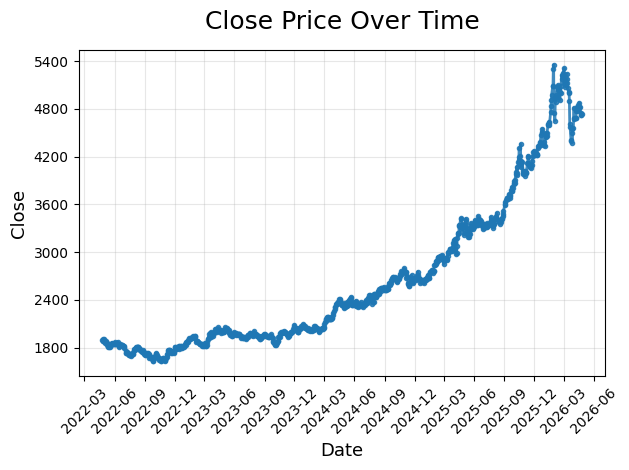

In [93]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.ticker import MaxNLocator


plt.plot(
    ts_combined["Date"],
    ts_combined["Close"],
    linewidth=2,
    marker="o",
    markersize=3,
    alpha=0.85
)

plt.title("Close Price Over Time", fontsize=18, pad=15)
plt.xlabel("Date", fontsize=13)
plt.ylabel("Close", fontsize=13)

# Improve x-axis date formatting
plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))

# Reduce number of y-axis labels
plt.gca().yaxis.set_major_locator(MaxNLocator(nbins=8))

plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [95]:
ts_combined.describe()

,Date,Close,time_index
count,1008,1008.000000,1008.000000
mean,2024-04-24 18:02:51.428571,2639.837996,504.500000
min,2022-04-25 00:00:00,1630.900000,1.000000
25%,2023-04-25 18:00:00,1933.550000,252.750000
50%,2024-04-25 12:00:00,2332.300000,504.500000
75%,2025-04-25 18:00:00,3245.400000,756.250000
max,2026-04-24 00:00:00,5354.800000,1008.000000
std,NaN,944.997688,291.128837


In [94]:
ts_combined["time_index"] = np.arange(1, len(ts_combined) + 1)

In [107]:
type(X_time)

pandas.DataFrame

In [ ]:
ts_combined["time_index"] = np.arange(1, len(ts_combined) + 1)

X_time = ts_combined[["time_index"]]
y_time = ts_combined["Close"]




In [109]:
X_time

,time_index
249,1
248,2
247,3
246,4
245,5
...,...
4,1004
3,1005
2,1006
1,1007


In [118]:
future = pd.DataFrame({'time_index':[1009,1010]}).set_index('time_index')

future


""
time_index
1009
1010


In [119]:

trend_model = LinearRegression()
trend_model.fit(X_time, y_time)

trend_pred = trend_model.predict(X_time)

trend_r2 = r2_score(y_time, trend_pred)
trend_rmse = root_mean_squared_error(y_time, trend_pred)

In [120]:
f = trend_model.predict(future)

/Users/karen/Desktop/aca/lab/python/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


ValueError: at least one array or dtype is required

In [ ]:
trend_pred = trend_model.predict(pd.nd.array(1009))

/Users/karen/Desktop/aca/lab/python/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


ValueError: Expected 2D array, got scalar array instead:
array=1009.
Reshape your data either using array.reshape(-1, 1) if your data has a single feature or array.reshape(1, -1) if it contains a single sample.

In [99]:
trend_r2

0.824675064139498

In [101]:
trend_rmse

395.49141415381337

In [102]:
X_time

,time_index
249,1
248,2
247,3
246,4
245,5
...,...
4,1004
3,1005
2,1006
1,1007
